In [7]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import kagglehub
import os  

In [8]:
df = pd.read_csv("https://raw.githubusercontent.com/mikvyork/glocal_capstone/refs/heads/main/DATA%20SOURCES/pub0725.csv")

### **Initial Exploration**


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114155 entries, 0 to 114154
Data columns (total 60 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   REC_NUM   114155 non-null  int64  
 1   SURVYEAR  114155 non-null  int64  
 2   SURVMNTH  114155 non-null  int64  
 3   LFSSTAT   114155 non-null  int64  
 4   PROV      114155 non-null  int64  
 5   CMA       114155 non-null  int64  
 6   AGE_12    114155 non-null  int64  
 7   AGE_6     22695 non-null   float64
 8   GENDER    114155 non-null  int64  
 9   MARSTAT   114155 non-null  int64  
 10  EDUC      114155 non-null  int64  
 11  MJH       66992 non-null   float64
 12  EVERWORK  47163 non-null   float64
 13  FTPTLAST  7120 non-null    float64
 14  COWMAIN   74112 non-null   float64
 15  IMMIG     114155 non-null  int64  
 16  NAICS_21  74112 non-null   float64
 17  NOC_10    74112 non-null   float64
 18  NOC_43    74112 non-null   float64
 19  YABSENT   9290 non-null    float64
 20  WKSA

In [10]:
df.head(5)

,REC_NUM,SURVYEAR,SURVMNTH,LFSSTAT,PROV,CMA,AGE_12,AGE_6,GENDER,MARSTAT,...,LKATADS,LKANSADS,LKOTHERN,PRIORACT,YNOLOOK,TLOLOOK,SCHOOLN,EFAMTYPE,AGYOWNK,FINALWT
0,1,2025,7,1,35,4,5,NaN,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2,NaN,1055
1,2,2025,7,1,24,0,6,NaN,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3,1.0,127
2,3,2025,7,1,13,0,4,NaN,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2,NaN,60
3,4,2025,7,1,35,4,7,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3,2.0,227
4,5,2025,7,4,24,0,12,NaN,2,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,297


In [11]:
df.columns

Index(['REC_NUM', 'SURVYEAR', 'SURVMNTH', 'LFSSTAT', 'PROV', 'CMA', 'AGE_12',
       'AGE_6', 'GENDER', 'MARSTAT', 'EDUC', 'MJH', 'EVERWORK', 'FTPTLAST',
       'COWMAIN', 'IMMIG', 'NAICS_21', 'NOC_10', 'NOC_43', 'YABSENT',
       'WKSAWAY', 'PAYAWAY', 'UHRSMAIN', 'AHRSMAIN', 'FTPTMAIN', 'UTOTHRS',
       'ATOTHRS', 'HRSAWAY', 'YAWAY', 'PAIDOT', 'UNPAIDOT', 'XTRAHRS', 'WHYPT',
       'TENURE', 'PREVTEN', 'HRLYEARN', 'UNION', 'PERMTEMP', 'ESTSIZE',
       'FIRMSIZE', 'DURUNEMP', 'FLOWUNEM', 'UNEMFTPT', 'WHYLEFTO', 'WHYLEFTN',
       'DURJLESS', 'AVAILABL', 'LKPUBAG', 'LKEMPLOY', 'LKRELS', 'LKATADS',
       'LKANSADS', 'LKOTHERN', 'PRIORACT', 'YNOLOOK', 'TLOLOOK', 'SCHOOLN',
       'EFAMTYPE', 'AGYOWNK', 'FINALWT'],
      dtype='object')

In [12]:
df['LFSSTAT'].describe()

count    114155.000000
mean          2.276405
std           1.395857
min           1.000000
25%           1.000000
50%           1.000000
75%           4.000000
max           4.000000
Name: LFSSTAT, dtype: float64

In [13]:
df['LFSSTAT'].value_counts()

LFSSTAT
1    57702
4    42092
2     9290
3     5071
Name: count, dtype: int64

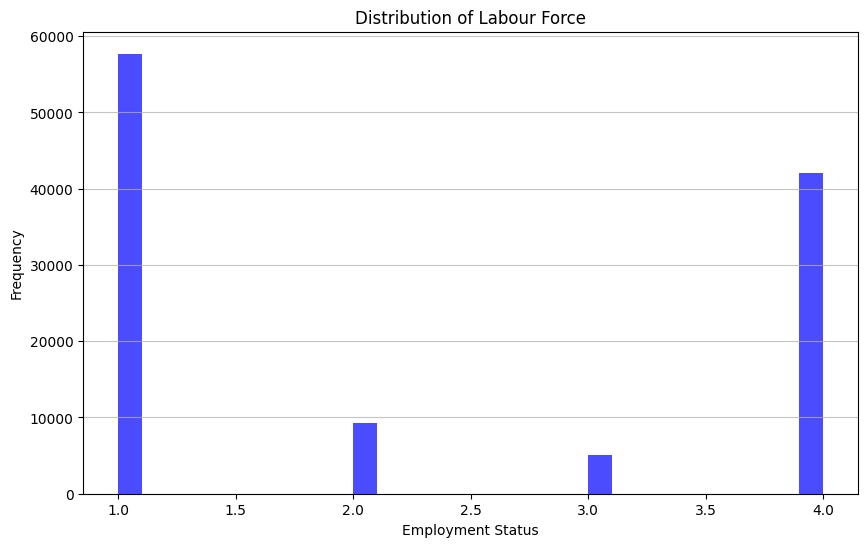

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df['LFSSTAT'], bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Labour Force')
plt.xlabel('Employment Status')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [16]:
df.columns

Index(['REC_NUM', 'SURVYEAR', 'SURVMNTH', 'LFSSTAT', 'PROV', 'CMA', 'AGE_12',
       'AGE_6', 'GENDER', 'MARSTAT', 'EDUC', 'MJH', 'EVERWORK', 'FTPTLAST',
       'COWMAIN', 'IMMIG', 'NAICS_21', 'NOC_10', 'NOC_43', 'YABSENT',
       'WKSAWAY', 'PAYAWAY', 'UHRSMAIN', 'AHRSMAIN', 'FTPTMAIN', 'UTOTHRS',
       'ATOTHRS', 'HRSAWAY', 'YAWAY', 'PAIDOT', 'UNPAIDOT', 'XTRAHRS', 'WHYPT',
       'TENURE', 'PREVTEN', 'HRLYEARN', 'UNION', 'PERMTEMP', 'ESTSIZE',
       'FIRMSIZE', 'DURUNEMP', 'FLOWUNEM', 'UNEMFTPT', 'WHYLEFTO', 'WHYLEFTN',
       'DURJLESS', 'AVAILABL', 'LKPUBAG', 'LKEMPLOY', 'LKRELS', 'LKATADS',
       'LKANSADS', 'LKOTHERN', 'PRIORACT', 'YNOLOOK', 'TLOLOOK', 'SCHOOLN',
       'EFAMTYPE', 'AGYOWNK', 'FINALWT'],
      dtype='object')

In [17]:
main = df[['LFSSTAT','AGE_12','GENDER','MARSTAT','EDUC','MJH','FTPTLAST','COWMAIN','IMMIG','NAICS_21','NOC_43','PRIORACT','SCHOOLN','EFAMTYPE']]

In [19]:
main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114155 entries, 0 to 114154
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   LFSSTAT   114155 non-null  int64  
 1   AGE_12    114155 non-null  int64  
 2   GENDER    114155 non-null  int64  
 3   MARSTAT   114155 non-null  int64  
 4   EDUC      114155 non-null  int64  
 5   MJH       66992 non-null   float64
 6   FTPTLAST  7120 non-null    float64
 7   COWMAIN   74112 non-null   float64
 8   IMMIG     114155 non-null  int64  
 9   NAICS_21  74112 non-null   float64
 10  NOC_43    74112 non-null   float64
 11  PRIORACT  4735 non-null    float64
 12  SCHOOLN   84218 non-null   float64
 13  EFAMTYPE  114155 non-null  int64  
dtypes: float64(7), int64(7)
memory usage: 12.2 MB


# **Cleaning Stage**